<a href="https://colab.research.google.com/github/hyunkyung31/DeepLearningProject/blob/main/yuri/0713_inception_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import urllib.request
import zipfile
dataset_url = "/content/drive/MyDrive/바이오메디컬AI/🐥new_2_project/04_DL_project/02_dataset/CADICA.zip"
with zipfile.ZipFile("/content/drive/MyDrive/바이오메디컬AI/🐥new_2_project/04_DL_project/02_dataset/CADICA.zip", "r") as zip_ref:
     zip_ref.extractall("./CADICA")
     print("압축 해제 완료!")

압축 해제 완료!


In [2]:
from pathlib import Path
import pandas as pd
from torch.utils.data import DataLoader
csv_path = "/content/drive/MyDrive/바이오메디컬AI/🐥new_2_project/04_DL_project/08_전처리/common_split.csv"
df = pd.read_csv(csv_path)

base = Path("/content/CADICA/CADICA/selectedVideos")

def expand_to_frames(row):
    v_dir = base / row.patient_id / row.video_id / "input"
    if not v_dir.exists():
        return []
    frame_rows = []
    for png_path in sorted(v_dir.glob("*.png")):
        frame_rows.append({
            "patient_id": row.patient_id,
            "video_id": row.video_id,
            "frame_path": str(png_path),
            "frame_id": png_path.stem,          # 예: p1_v2_00015
            "label": row.label,
            "view": row.view,
            "split": row.split,                  # video의 split을 그대로 물려받음
            "has_groundtruth": row.has_groundtruth,
        })
    return frame_rows

all_frames = []
for _, row in df.iterrows():
    all_frames.extend(expand_to_frames(row))

frame_df = pd.DataFrame(all_frames)
print("총 프레임 수:", len(frame_df))
print(frame_df.split.value_counts())
frame_df.head()

총 프레임 수: 15799
split
train    13316
val       1396
test      1087
Name: count, dtype: int64


,patient_id,video_id,frame_path,frame_id,label,view,split,has_groundtruth
0,p1,v2,/content/CADICA/CADICA/selectedVideos/p1/v2/in...,p1_v2_00001,lesion,<bound method Series.view of patient_id ...,train,True
1,p1,v2,/content/CADICA/CADICA/selectedVideos/p1/v2/in...,p1_v2_00002,lesion,<bound method Series.view of patient_id ...,train,True
2,p1,v2,/content/CADICA/CADICA/selectedVideos/p1/v2/in...,p1_v2_00003,lesion,<bound method Series.view of patient_id ...,train,True
3,p1,v2,/content/CADICA/CADICA/selectedVideos/p1/v2/in...,p1_v2_00004,lesion,<bound method Series.view of patient_id ...,train,True
4,p1,v2,/content/CADICA/CADICA/selectedVideos/p1/v2/in...,p1_v2_00005,lesion,<bound method Series.view of patient_id ...,train,True


In [3]:
frame_df.to_csv("/content/mapped_frames.csv", index=False)

In [4]:
from torch.utils.data import Dataset
from PIL import Image

class CADICADataset(Dataset):
  def __init__(self, frame_df, transform=None):
    self.df = frame_df
    self.transform = transform

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    row = self.df.iloc[idx]
    image = Image.open(row['frame_path']).convert('RGB')
    label = 1 if row['label'] == 'lesion' else 0

    if self.transform:
      image = self.transform(image)

    return image, label


In [5]:
train_df = frame_df[frame_df['split'] == 'train']

train_dataset = CADICADataset(train_df, transform=None)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f"데이터 로더가 성공적으로 생성되었습니다. 총 배치 수: {len(train_loader)}")

데이터 로더가 성공적으로 생성되었습니다. 총 배치 수: 417


In [6]:
from torchvision import transforms

def get_model_transforms(model_type='inception'):
  size = 299 if model_type=='inception' else 380
  return transforms.Compose([
      transforms.Resize((size, size)),
      transforms.RandomHorizontalFlip(p=0.5),
      transforms.RandomRotation(degrees=15),
      transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
      transforms.ToTensor(),
      transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
  ])

In [7]:
train_transform = get_model_transforms(model_type='inception') # 증강 포함

val_transform = transforms.Compose([ # 증강 제외 / resize, totensor, normalize 만 사용
    transforms.Resize((299,299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

train_df = frame_df[frame_df['split'] == 'train']
val_df = frame_df[frame_df['split'] == 'val']

train_dataset = CADICADataset(train_df, transform=train_transform)
val_dataset = CADICADataset(val_df, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [11]:
# 전이 학습

import torch
import torch.nn as nn
from torchvision import models

def get_model(model_type='inception'):
  if model_type == 'inception':
    model = models.inception_v3(weights='DEFAULT') # 가장 성능이 좋은 사전 학습 가중치 가져오기
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, 2)

  elif model_type == 'efficientnet':
    model = models.efficientnet_b4(weights='DEFAULT')
    num_ftrs = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_ftrs, 2)

  return model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = get_model('inception').to(device)

In [18]:
# 학습
num_epochs = 5
optimizer = torch.optim.Adam(model.parameters(), lr=0.00001)
criterion = nn.CrossEntropyLoss()
best_accuracy = 0.0
for epoch in range(num_epochs):
  model.train()
  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)

    optimizer.zero_grad()
    outputs = model(images)
    if isinstance(outputs, tuple):
      outputs = outputs[0]
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

  model.eval()
  with torch.no_grad():
    correct = 0
    total = 0
    for val_images, val_labels in val_loader:
        val_images, val_labels = val_images.to(device), val_labels.to(device)

        outputs = model(val_images)
        # Inception 모델인 경우 출력값 추출
        if isinstance(outputs, tuple):
            outputs = outputs[0]

        # 가장 높은 확률을 가진 클래스를 예측값으로 선정
        _, predicted = torch.max(outputs.data, 1)

        # 전체 개수와 맞은 개수 누적
        total += val_labels.size(0)
        correct += (predicted == val_labels).sum().item()

    # 정확도 출력
    accuracy = 100 * correct / total
    print(f'Epoch [{epoch+1}/{num_epochs}], Accuracy: {accuracy:.2f}%')

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        torch.save(model.state_dict(), 'best_model.pth')

Epoch [1/5], Accuracy: 73.78%
Epoch [2/5], Accuracy: 72.78%
Epoch [3/5], Accuracy: 72.13%
Epoch [4/5], Accuracy: 71.56%
Epoch [5/5], Accuracy: 70.85%


# lr=0.0001
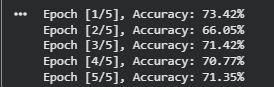

# lr = 0.00001
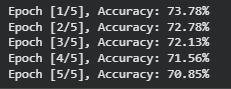

In [13]:
# 학습
patience = 3
trigger_times = 0
num_epochs = 15
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.00001,
    )
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer,
#     mode='max',
#     factor=0.5,
#     patience=2
#     )
criterion = nn.CrossEntropyLoss()
best_accuracy = 0.0
for epoch in range(num_epochs):
  model.train()
  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)

    optimizer.zero_grad()
    outputs = model(images)
    if isinstance(outputs, tuple):
      outputs = outputs[0]
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

  model.eval()
  with torch.no_grad():
    correct = 0
    total = 0
    for val_images, val_labels in val_loader:
        val_images, val_labels = val_images.to(device), val_labels.to(device)

        outputs = model(val_images)
        # Inception 모델인 경우 출력값 추출
        if isinstance(outputs, tuple):
            outputs = outputs[0]

        # 가장 높은 확률을 가진 클래스를 예측값으로 선정
        _, predicted = torch.max(outputs.data, 1)

        # 전체 개수와 맞은 개수 누적
        total += val_labels.size(0)
        correct += (predicted == val_labels).sum().item()

    # 정확도 출력
    accuracy = 100 * correct / total
    print(f'Epoch [{epoch+1}/{num_epochs}], Accuracy: {accuracy:.2f}%')

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        torch.save(model.state_dict(), 'best_model.pth')
        print(f'Best model saved with accuracy: {accuracy:.2f}%')
        trigger_times = 0  # 성능이 올랐으므로 카운트 초기화
    else:
        trigger_times += 1 # 성능이 안 올랐으므로 카운트 증가
        print(f'trigger_times: {trigger_times}/{patience}')

        if trigger_times >= patience:
            print(f'Training stopped at epoch {epoch+1}')
            break # 학습 강제 중단

Epoch [1/15], Accuracy: 72.64%
Best model saved with accuracy: 72.64%
Epoch [2/15], Accuracy: 69.20%
trigger_times: 1/3
Epoch [3/15], Accuracy: 68.41%
trigger_times: 2/3
Epoch [4/15], Accuracy: 69.27%
trigger_times: 3/3
Training stopped at epoch 4


In [ ]:
# 0.00001 기준 최대 73% 정확도